# 🤖 2. Selective Preprocessing - Regression model with Dropouts
**Deep learning model for blue fundus eye pictures regression**

The purpose of this notebook is to evaluate a regression CNN model across different selective preprocessing scenarios.

The regression target is:

- `target_SE`: spherical equivalent value in diopters.

The same lightweight CNN architecture is trained on four preprocessing scenarios:The final purpose of this notebook is to apply last notebook's regession deep learning model (small_cnn_regrss) to different levels of preprocessing on the fundus images, so as to set a baseline for the project depending on the level of preprocessing. There will be 4 scenarios performed:

A. Normalization only
- With RGB conversion and normalization to [0–1].
- No geometry: no circle detection, nor padding/resizing (only dataloader resizer for 224×224 pixels).
- No CLAHE.
- No Augmentations.

B. Geometry + Normalization
- With RGB conversion and normalization to [0–1].
- With geometry: fundus circle detection + circular crop + padding to square + resizing to 224×224.
- No CLAHE.
- No Augmentations.

C. Geometry + Normalization + Illumination (no Augmentantions)
- With RGB conversion and normalization to [0–1].
- With geometry: fundus circle detection + circular crop + padding to square + resizing to 224×224.
- With CLAHE (luminance or blue can be chosen).
- No Augmentations.

D. Geometry + Normalization + Augmentations (no illumination)
- With RGB conversion and normalization to [0–1].
- With geometry: fundus circle detection + circular crop + padding to square + resizing to 224×224.
- No CLAHE.
- With geometric Augmentations: flip, light rotation and zoom applied at dataloader.

## ⚙️ 1. Setting up



In [1]:
from pathlib import Path #useful since it makes path use easier (can append paths and more)
import os, random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import importlib
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# from sklearn.model_selection import train_test_split - not necessary, we import splits now
# from sklearn.utils.class_weight import compute_class_weight - en regrss no se usan
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)

# Load configurable project paths ============================================================

# Project root detection
PROJECT_ROOT = Path.cwd().resolve()

while not (PROJECT_ROOT / "config.yaml").exists():
    if PROJECT_ROOT == PROJECT_ROOT.parent:
        raise FileNotFoundError("config.yaml was not found. Make sure it is located in the project root.")
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

importlib.invalidate_caches()

from src.paths import (
    load_config,
    get_paths,
    validate_main_structure,
    print_paths
)

cfg = load_config(PROJECT_ROOT / "config.yaml")

paths = get_paths(cfg)
validate_main_structure(paths)

# General settings ===========================================================

SEED = int(cfg["settings"]["seed"])
IMG_SIZE = tuple(cfg["settings"]["image_size"]) #from config.yaml - must match the preprocessed size
BATCH = int(cfg["settings"]["batch_size"]) #from config.yaml - number of images preprocessed in each training step
AUTOTUNE = tf.data.AUTOTUNE #allows for paralelism automation

tf.keras.utils.set_random_seed(SEED)  #locks Python, NumPy and TF seed
tf.config.experimental.enable_op_determinism() #makes same deterministic ops

# Paths ===========================================================

IMAGES_DIR = paths["images"]
TABLES_DIR = paths["tables"]
SPLITS_DIR = paths["splits"]
MODELS_DIR = paths["models"]

for folder in [IMAGES_DIR, TABLES_DIR, SPLITS_DIR, MODELS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Images dir:", IMAGES_DIR)
print("Tables dir:", TABLES_DIR)
print("Splits dir:", SPLITS_DIR)
print("Models dir:", MODELS_DIR)
print("IMG_SIZE:", IMG_SIZE)
print("BATCH:", BATCH)
print("SEED:", SEED)

Project root: C:\Users\paula\0B_TFGBiomed_Exe
Images dir: C:\Users\paula\0B_TFGBiomed_Exe\Images
Tables dir: C:\Users\paula\0B_TFGBiomed_Exe\Tables
Splits dir: C:\Users\paula\0B_TFGBiomed_Exe\Splits
Models dir: C:\Users\paula\0B_TFGBiomed_Exe\ModelsToSave
IMG_SIZE: (224, 224)
BATCH: 32
SEED: 42


In [2]:
# Selective preprocessing output folders ===========================================================

SPLIT_ROOT = SPLITS_DIR / "Regression" / "SelectivePreproc"
MODELS_DIR_SELECTIVE = MODELS_DIR / "WithDropout" / "SelectivePreproc" / "Regression"

SPLIT_ROOT.mkdir(parents=True, exist_ok=True)
MODELS_DIR_SELECTIVE.mkdir(parents=True, exist_ok=True)

print("Split root:", SPLIT_ROOT)
print("Models selective output:", MODELS_DIR_SELECTIVE)

Split root: C:\Users\paula\0B_TFGBiomed_Exe\Splits\Regression\SelectivePreproc
Models selective output: C:\Users\paula\0B_TFGBiomed_Exe\ModelsToSave\WithDropout\SelectivePreproc\Regression


In [3]:
# Paths to selectively preprocessed sets of images
SCENARIO_TABLES = {
    "A_Raw_minimal": TABLES_DIR / "MatchTables" / "TablaMatch_SCENARIO.A.xlsx",         # Raw with minimal preproc
    "B_GeoNorm": TABLES_DIR / "MatchTables" / "TablaMatch_SCENARIO.B.xlsx",             # geometry + normalization
    "C_GeoNorm_Illum_NoAug": TABLES_DIR / "MatchTables" / "TablaMatch_SCENARIO.C.xlsx", # geometry + normalization + illumination 
    "D_GeoNorm_Aug_NoIllum": TABLES_DIR / "MatchTables" / "TablaMatch_SCENARIO.B.xlsx" # geometry + normalization + augmentations - there is no such path, will be using B for D
}

EXPERIMENTS = [ # (name, data_root, augment_in_loader, normalization)
    {
        "name": "A_Raw_minimal",
        "table": SCENARIO_TABLES["A_Raw_minimal"],
        "do_aug": False,
        "normalization": "0-1"
    },
    {
        "name": "B_GeoNorm",
        "table": SCENARIO_TABLES["B_GeoNorm"],
        "do_aug": False,
        "normalization": "0-1"
    },
    {
        "name": "C_GeoNorm_Illum_NoAug",
        "table": SCENARIO_TABLES["C_GeoNorm_Illum_NoAug"],
        "do_aug": False,
        "normalization": "0-1"
    },
    {
        "name": "D_GeoNorm_Aug_NoIllum",
        "table": SCENARIO_TABLES["D_GeoNorm_Aug_NoIllum"],  #makes use of geom+norm to make augmentations without illumination
        "do_aug": True,
        "normalization": "0-1"
    }
]

for name, path in SCENARIO_TABLES.items():
    print(name, "exists:", path.exists(), "|", path)
    assert path.exists(), f"Missing scenario table: {path}"

A_Raw_minimal exists: True | C:\Users\paula\0B_TFGBiomed_Exe\Tables\MatchTables\TablaMatch_SCENARIO.A.xlsx
B_GeoNorm exists: True | C:\Users\paula\0B_TFGBiomed_Exe\Tables\MatchTables\TablaMatch_SCENARIO.B.xlsx
C_GeoNorm_Illum_NoAug exists: True | C:\Users\paula\0B_TFGBiomed_Exe\Tables\MatchTables\TablaMatch_SCENARIO.C.xlsx
D_GeoNorm_Aug_NoIllum exists: True | C:\Users\paula\0B_TFGBiomed_Exe\Tables\MatchTables\TablaMatch_SCENARIO.B.xlsx


## 🛠️  2. Helpers preparation

To keep the codebase clean and efficient, several helper functions were implemented.  
These functions encapsulate small, reusable tasks that will be required multiple times throughout the preprocessing pipeline.

####  2.1 Loading base table

In [4]:
base_df = pd.read_excel(SCENARIO_TABLES["A_Raw_minimal"])

# Keep only rows with valid paths and regression targets
base_df = base_df[base_df["image_path"].notna()].copy()
base_df = base_df[base_df["filename"].notna()].copy()
base_df = base_df[base_df["target_SE"].notna()].copy()

base_df["image_path"] = base_df["image_path"].astype(str)
base_df["filename"] = base_df["filename"].astype(str)
base_df["patient_id"] = base_df["patient_id"].astype(str).str.upper().str.strip()
base_df["target_SE"] = pd.to_numeric(base_df["target_SE"], errors="coerce")

base_df = base_df.dropna(
    subset=["image_path", "filename", "patient_id", "target_SE"]
).copy()

print("Total valid images for regression:", len(base_df))

print("\nTarget SE summary:")
print(base_df["target_SE"].describe())

base_df.head()

Total valid images for regression: 2126

Target SE summary:
count    2126.000000
mean        0.021696
std         2.109061
min       -20.375000
25%        -0.250000
50%         0.000000
75%         0.750000
max         9.000000
Name: target_SE, dtype: float64


,image_path,filename,patient_id,image_date_raw,image_date,modality,eye,nhc,FechaNacimiento,Edad,...,match_type,target_SE,class_label,original_image_path,preprocessing,image_size,detect_fundus,pad_and_resize,clahe_applied,clahe_mode
0,C:\Users\paula\0B_TFGBiomed\Images\02_Selectiv...,A6138_17092024_165654_Color_R_001.jpg,A6138,17092024,2024-09-17,Color,R,A6138,2020-06-03,6,...,id+date,0.000,0,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,A_Raw_minimal,224,False,False,False,none
1,C:\Users\paula\0B_TFGBiomed\Images\02_Selectiv...,A6138_17092024_165721_Color_L_001.jpg,A6138,17092024,2024-09-17,Color,L,A6138,2020-06-03,6,...,id+date,0.000,0,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,A_Raw_minimal,224,False,False,False,none
2,C:\Users\paula\0B_TFGBiomed\Images\02_Selectiv...,A6140_11122023_191157_IR_R_001.jpg,A6140,11122023,2023-12-11,IR,R,A6140,1975-10-06,51,...,id+date,-2.250,1,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,A_Raw_minimal,224,False,False,False,none
3,C:\Users\paula\0B_TFGBiomed\Images\02_Selectiv...,A6140_11122023_191221_IR_L_001.jpg,A6140,11122023,2023-12-11,IR,L,A6140,1975-10-06,51,...,id+date,-0.625,1,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,A_Raw_minimal,224,False,False,False,none
4,C:\Users\paula\0B_TFGBiomed\Images\02_Selectiv...,A6142_12042023_153339_Color_R_001.jpg,A6142,12042023,2023-04-12,Color,R,A6142,2000-07-08,26,...,id+date,0.000,0,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,A_Raw_minimal,224,False,False,False,none


SE distribution:

The dataset used for this regression notebook contains **2,126 valid images** with available **SE** values. The target distribution is strongly centred around **0 D**, with a mean of **0.022 D**, a median of **0 D**, and an interquartile range from **-0.25 D** to **0.75 D**. This is important because the regression problem is not evenly distributed across the full refractive range. Most images correspond to values close to emmetropia or low refractive error, while the extreme values are much less frequent. The target range is wide (**-20.375 D** to **9.0 D**), but most samples are concentrated in a narrow interval around zero.

Because of this distribution, a model can obtain a relatively low MAE by predicting values close to **0 D** for most images. Therefore, MAE must be interpreted together with **R²**, prediction plots and residual plots. A low MAE alone does not necessarily mean that the model has learned clinically meaningful SE information from the retinal images.


#### ✂️  2.2 Splitting the dataset
Stratified (avoids bias since myope class is slightly bigger than the normal one) 80/10/10 split by chosen root dataset.

In [5]:
# Load existing patient-level regression splits created in 00_CreatePatientLevelSplits_Classf_Regrss.ipynb

def load_existing_scenario_split(scenario_name: str) -> dict:
    scenario_split_dir = SPLIT_ROOT / scenario_name

    train_csv = scenario_split_dir / "train.csv"
    val_csv   = scenario_split_dir / "val.csv"
    test_csv  = scenario_split_dir / "test.csv"

    for csv_path in [train_csv, val_csv, test_csv]:
        if not csv_path.exists():
            raise FileNotFoundError(
                f"Missing split file: {csv_path}. "
                "Run 00_CreatePatientLevelSplits_Classf_Regrss.ipynb first."
            )

    return {
        "train": train_csv,
        "val": val_csv,
        "test": test_csv,
    }


def check_no_overlap(train_df, val_df, test_df, column: str, name: str) -> None:
    train_values = set(train_df[column].astype(str))
    val_values   = set(val_df[column].astype(str))
    test_values  = set(test_df[column].astype(str))

    assert len(train_values & val_values) == 0, f"{name}: overlap between train and val"
    assert len(train_values & test_values) == 0, f"{name}: overlap between train and test"
    assert len(val_values & test_values) == 0, f"{name}: overlap between val and test"

    print(f"OK: no {name} overlap across train/val/test.")


SCENARIO_SPLITS = {}

for exp in EXPERIMENTS:
    name = exp["name"]
    SCENARIO_SPLITS[name] = load_existing_scenario_split(name)

    train_df = pd.read_csv(SCENARIO_SPLITS[name]["train"])
    val_df   = pd.read_csv(SCENARIO_SPLITS[name]["val"])
    test_df  = pd.read_csv(SCENARIO_SPLITS[name]["test"])

    print(f"\n===== {name} =====")
    print("Train:", len(train_df))
    print("Val:  ", len(val_df))
    print("Test: ", len(test_df))

    check_no_overlap(train_df, val_df, test_df, "patient_id", f"{name} patient")
    check_no_overlap(train_df, val_df, test_df, "image_path", f"{name} image")

    print("\nTrain target SE summary:")
    print(train_df["target_SE"].describe())

    print("\nVal target SE summary:")
    print(val_df["target_SE"].describe())

    print("\nTest target SE summary:")
    print(test_df["target_SE"].describe())


===== A_Raw_minimal =====
Train: 1700
Val:   209
Test:  217
OK: no A_Raw_minimal patient overlap across train/val/test.
OK: no A_Raw_minimal image overlap across train/val/test.

Train target SE summary:
count    1700.000000
mean        0.006029
std         2.173365
min       -20.375000
25%        -0.250000
50%         0.000000
75%         0.625000
max         7.750000
Name: target_SE, dtype: float64

Val target SE summary:
count    209.000000
mean       0.069976
std        1.860834
min      -14.000000
25%       -0.375000
50%        0.000000
75%        0.750000
max        5.000000
Name: target_SE, dtype: float64

Test target SE summary:
count    217.000000
mean       0.097926
std        1.806159
min       -6.500000
25%       -0.250000
50%        0.000000
75%        0.750000
max        9.000000
Name: target_SE, dtype: float64

===== B_GeoNorm =====
Train: 1700
Val:   209
Test:  217
OK: no B_GeoNorm patient overlap across train/val/test.
OK: no B_GeoNorm image overlap across train/val/t

The four selective preprocessing scenarios use the same patient-level split structure: **1,700 images for training**, **209 for validation** and **217 for testing**. The checks confirm that there is **no patient overlap** and **no image overlap** between train, validation and test sets. 

The SE distributions are also broadly consistent across train, validation and test. However, the training set contains the most extreme negative value (**-20.375 D**), while the test set ranges from **-6.5 D** to **9.0 D**. This means that the model sees a wider negative range during training than during testing, but the general pattern remains the same: the target is concentrated around **0 D**.


#### 🧮  2.3 Decoder and normalizer
Now we move onto building efficient TensorFlow datasets (tf.data pipeline) from image paths and labels, applying decoding, resizing, batching, and lightweight data augmentations for training. In other words, we are receiving a disk path and giving a tensor back.

Note: a tensor is the basic structure in TensorFlow (in deep learning frameworks). A picture would be a 3D tensor (hxwxchannels) and a batch of pictures would be a 4D tensor (hxwxcxbatch)

In [6]:
IMAGENET_MEAN = tf.constant([0.485, 0.456, 0.406], tf.float32) #mean pixels intensity on red, green, blue channels
IMAGENET_STD  = tf.constant([0.229, 0.224, 0.225], tf.float32) #standard deviations on channels

def decode_img(path, label, normalization="0-1"):
    img = tf.io.read_file(path) #reades pic as bytes
    img = tf.image.decode_jpeg(img, channels=3) #decodes jpg into rgb tensor
    img = tf.image.convert_image_dtype(img, tf.float32) #converts to float [0,1]
    img = tf.image.resize(img, IMG_SIZE, method='bilinear') #rescales to 224x224
    img = normalize_tensor(img, mode=normalization)
    return img, tf.cast(label, tf.float32) #gives pic+label back so dataloader knows the class it belongs to 

def normalize_tensor(img_float01, mode="0-1"):
    # img_float01 into [0,1], float32
    if mode == "0-1":
        return img_float01
    if mode == "imagenet":
        return (img_float01 - IMAGENET_MEAN) / IMAGENET_STD
    if mode == "zscore":
        mean = tf.reduce_mean(img_float01, axis=[0,1], keepdims=True)
        std  = tf.math.reduce_std(img_float01, axis=[0,1], keepdims=True) + 1e-6
        return (img_float01 - mean) / std
    return img_float01

#### 🎭  2.4 Dataloader with(out) Lightweight augmentations
Creating the TensorFlow dataset (dataloader) with simple geometric transformations (or not) to improve generalization and reduce overfitting.

Shuffles and augmentations will only be applied if training=True

In [7]:
#Declare the type of augmentations to be carried out (if wanted)
augment = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"), #hozt flip (imitates eye flip)
    tf.keras.layers.RandomRotation(0.02), #slight rotation
    tf.keras.layers.RandomZoom(0.05), #slight random zoom
])

def make_ds(csv_path, training=False, normalization="0-1", do_aug=False): #creating the TensorFlow dataset
    split_df = pd.read_csv(csv_path) #cvs path is pic+label
    paths = split_df["image_path"].astype(str).values
    targets = split_df["target_SE"].astype("float32").values
    ds = tf.data.Dataset.from_tensor_slices((paths, targets))
    ds = ds.map(lambda p, y: decode_img(p, y, normalization), num_parallel_calls=AUTOTUNE) #applies decode_img on each image
    if training: #if training, it shuffles (so it learns with random order) and applies augmentations 
        ds = ds.shuffle(8192, seed=SEED, reshuffle_each_iteration=True)
        if do_aug:
            ds = ds.map(lambda x, y: (augment(x, training=True), y), num_parallel_calls=AUTOTUNE) #(aumentos)
    ds = ds.batch(BATCH).prefetch(AUTOTUNE) #prefetching makes pipeline faster; batch size declared up top
    return ds

#### 🟢  2.5 The regression model - small_cnn_regrss

Definition of the small_cnn architecture used as a first baseline regression model. This was model small_cnn_regrss on the Models_1FullPreproc.ipynb notebook.

In [8]:
def build_small_cnn_regrss(input_shape=(224, 224, 3)):
    inputs = keras.Input(shape=input_shape)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inputs) #progressively extracts characteristics
    x = layers.MaxPool2D()(x) #reduces resolution and makes more compact/robust representation
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x) #zero-padding on borders so input is same size as output (in case kernel and input are different sizes?)
    x = layers.MaxPool2D()(x)
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.GlobalAveragePooling2D()(x) #compacts activation maps into mean value (lees params and less overfitting than Flatten)
    x = layers.Dropout(0.3)(x) #randomly switches off 30% of neurons while training
    outputs = layers.Dense(1, activation="linear")(x) # Regression output: one continuous value, e.g. -2.75 diopters
    return keras.Model(inputs, outputs)

def compile_model_regrss():
    model_regrss = build_small_cnn_regrss()
    model_regrss.compile(optimizer=keras.optimizers.Adam(1e-3), #Adam optimizer with low error 
                  loss="mse", #adecuate for regression calculations (Mean Squared Error)
                  metrics=[keras.metrics.MeanAbsoluteError(name="mae"), keras.metrics.MeanSquaredError(name="mse")]) #Mean Absolute Error and accuracy metrics
    return model_regrss

In [9]:
example_model = compile_model_regrss()
example_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 128)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 93,377 (364.75 KB)

 Trainable params: 93,377 (364.75 KB)

 Non-trainable params: 0 (0.00 B)

#### ⏱️  2.6 Callbacks
Training monitors (earlystopping and learning-rate) scheduling for stability and later use.

In [10]:
def make_callbacks():
    return [ 
        keras.callbacks.EarlyStopping(monitor="val_mae", mode="min", patience=5, restore_best_weights=True), #if AUC is not better after 5 epochs, goes back to previous weights
        keras.callbacks.ReduceLROnPlateau( monitor="val_mae", mode="min", factor=0.3, patience=2),#if AUC stays the same value after 2 epochs, LR gets reduced multiplying it by 0.3
    ]

#### 📦  2.7 Training and evalutation wrappers
Utility functions to make predictions on the dataset and evaluate results by stablished metrics.

In [11]:
#This function gives back true labels and predicted labels so as to calculate metrics later on
def collect_preds(model, ds): #dataset as ds
    y_true, y_score = [], [] 
    for xb, yb in ds:
        p = model.predict(xb, verbose=0).ravel()
        y_true.extend(yb.numpy().tolist())
        y_score.extend(p.tolist())
    y_true = np.array(y_true).astype(int)
    y_score = np.array(y_score).astype(float)
    return y_true, y_score

#Gives back a dictionary with: model name, AUC, AP, accuracy @50% threshold, confusion matrix and classification report
def evaluate_on_test(name, model, test_ds, show_plots=True):
    y_true, y_pred = collect_preds(model, test_ds)
    
    errors = y_pred - y_true
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)

    #Metric 1: ROC / PR???
    if len(y_true) >= 2:
        r2 = r2_score(y_true, y_pred)
    else:
        r2 = np.nan

    #Metric 2: Confusion matrix & report???
    if show_plots:
        plt.figure(figsize=(5, 5))
        plt.scatter(y_true, y_pred, alpha=0.6)

        min_val = min(y_true.min(), y_pred.min())
        max_val = max(y_true.max(), y_pred.max())

        plt.plot([min_val, max_val], [min_val, max_val], "--", alpha=0.6)

        plt.xlabel("True SE (diopters)")
        plt.ylabel("Predicted SE (diopters)")
        plt.title(f"True vs Predicted – {name}")
        plt.grid(True)
        plt.show()

        plt.figure(figsize=(6, 4))
        plt.hist(errors, bins=30, alpha=0.8)
        plt.axvline(0, linestyle="--")
        plt.xlabel("Prediction error (predicted - true)")
        plt.ylabel("Frequency")
        plt.title(f"Error distribution – {name}")
        plt.grid(True)
        plt.show()

        plt.figure(figsize=(6, 4))
        plt.scatter(y_true, errors, alpha=0.6)
        plt.axhline(0, linestyle="--")
        plt.xlabel("True SE (diopters)")
        plt.ylabel("Prediction error")
        plt.title(f"Residuals – {name}")
        plt.grid(True)
        plt.show()

    return {
        "name": name,
        "MAE": float(mae),
        "MSE": float(mse),
        "RMSE": float(rmse),
        "R2": float(r2) if not np.isnan(r2) else np.nan,
        "mean_error": float(np.mean(errors)),
        "std_error": float(np.std(errors))
    }

#### 🧪  2.8 Running the experiment
Full pipeline of model.

In [12]:
def run_experiment(exp, epochs=10):
    name = exp["name"]
    normalization = exp["normalization"]
    do_aug = exp["do_aug"]

    print(f"\n===== Running {name} =====")

    # 1) Splits (by root)
    train_csv = SCENARIO_SPLITS[name]["train"]
    val_csv = SCENARIO_SPLITS[name]["val"]
    test_csv = SCENARIO_SPLITS[name]["test"]

    # 2) Datasets
    train_ds = make_ds(train_csv, training=True,  normalization=normalization, do_aug=do_aug)
    val_ds   = make_ds(val_csv,   training=False, normalization=normalization, do_aug=False)
    test_ds  = make_ds(test_csv,  training=False, normalization=normalization, do_aug=False)

    # 3) Model
    model = compile_model_regrss()
    
    # 4) callbacks
    cb = make_callbacks()

    # 5) Train
    history = model.fit(train_ds, validation_data=val_ds, epochs=epochs, callbacks=cb)

    # 6) Evaluate
    test_metrics = evaluate_on_test(name, model, test_ds, show_plots=True)
    print(test_metrics)
    
    return model, history, test_metrics, (train_ds, val_ds, test_ds)


## 🚀 3. The launching of the model

Now, we'll launch the regression (small_cnn_regrss), that is CPU friendly and compiles it with Adam and binary cross-entropy, adds AUC/accuracy metrics, uses early stopping and learning-rate reduction on plateau, computes class weights from the train split, and trains the model with the tf.data pipelines.

We'll be applying it on the 4 baselines:

🇦 2.1 Small CNN with raw images - Mere normalization.

🇧 2.2 Small CNN with no Illumination and no Augmentations - This time only geometry and normalization preprocessing are applied.

🇨 2.3 Small CNN with Illumination (no augmentations) - This time only geometry, normalization and illumination preprocessing are applied.

🇩 2.4 Small CNN with Augmentations (no illumination) - This time only geometry, normalization and augmentations are applied.


===== Running A_Raw_minimal =====
Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 71s 762ms/step - loss: 4.2190 - mae: 1.1778 - mse: 4.2190 - val_loss: 3.4563 - val_mae: 1.0072 - val_mse: 3.4563 - learning_rate: 0.0010
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 65s 685ms/step - loss: 4.9505 - mae: 1.2418 - mse: 4.9505 - val_loss: 3.4396 - val_mae: 1.0013 - val_mse: 3.4396 - learning_rate: 0.0010
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 61s 715ms/step - loss: 4.6041 - mae: 1.2342 - mse: 4.6041 - val_loss: 3.4402 - val_mae: 0.9962 - val_mse: 3.4402 - learning_rate: 0.0010
Epoch 4/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 67s 729ms/step - loss: 4.8135 - mae: 1.2719 - mse: 4.8135 - val_loss: 3.4435 - val_mae: 1.0057 - val_mse: 3.4435 - learning_rate: 0.0010
Epoch 5/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 67s 742ms/step - loss: 4.1916 - mae: 1.2006 - mse: 4.1916 - val_loss: 3.4402 - val_mae: 1.0013 - val_mse: 3.4402 - learning_rate: 0.0010
Epoch 6/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 57s 551ms/step - loss: 4.6489 - mae: 1.2403 - mse: 4

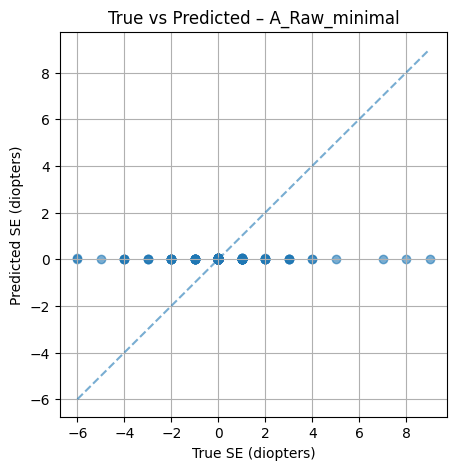

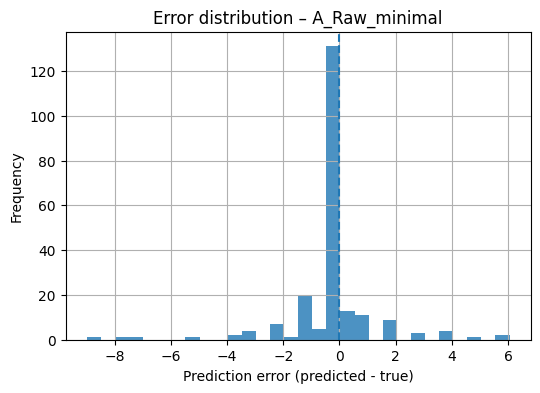

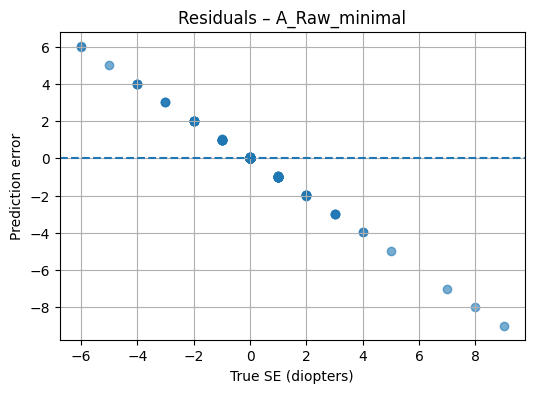

{'name': 'A_Raw_minimal', 'MAE': 0.7515711475127218, 'MSE': 2.666530933628135, 'RMSE': 1.632951601740889, 'R2': -0.0022531180346359037, 'mean_error': -0.07325949103030707, 'std_error': 1.6313074451500906}

===== Running B_GeoNorm =====
Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 42s 677ms/step - loss: 4.2202 - mae: 1.1815 - mse: 4.2202 - val_loss: 3.4419 - val_mae: 1.0106 - val_mse: 3.4419 - learning_rate: 0.0010
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 37s 663ms/step - loss: 4.9477 - mae: 1.2424 - mse: 4.9477 - val_loss: 3.4172 - val_mae: 1.0137 - val_mse: 3.4172 - learning_rate: 0.0010
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 38s 680ms/step - loss: 4.5753 - mae: 1.2383 - mse: 4.5753 - val_loss: 3.4074 - val_mae: 1.0082 - val_mse: 3.4074 - learning_rate: 0.0010
Epoch 4/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 38s 690ms/step - loss: 4.7727 - mae: 1.2832 - mse: 4.7727 - val_loss: 3.4158 - val_mae: 1.0074 - val_mse: 3.4158 - learning_rate: 0.0010
Epoch 5/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 37s 670ms/step - loss: 4.1

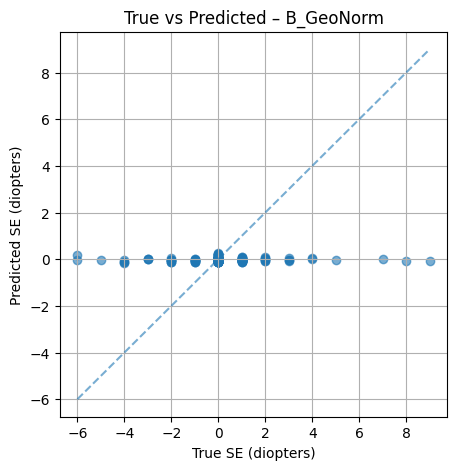

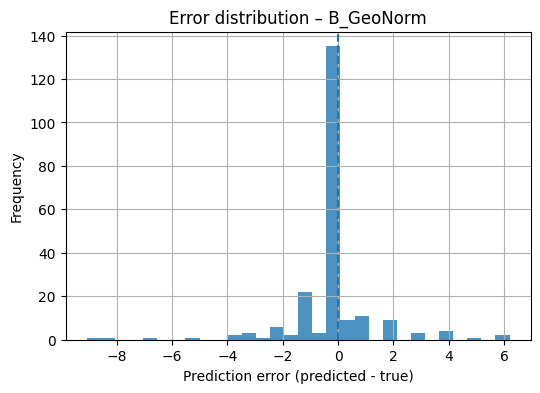

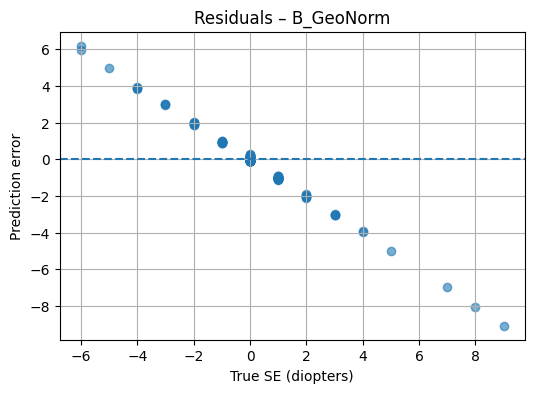

{'name': 'B_GeoNorm', 'MAE': 0.777140316079169, 'MSE': 2.6704852570349153, 'RMSE': 1.6341619433320906, 'R2': -0.0037394060480924196, 'mean_error': -0.10512669096284542, 'std_error': 1.630777003726174}

===== Running C_GeoNorm_Illum_NoAug =====
Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 42s 685ms/step - loss: 4.2212 - mae: 1.1778 - mse: 4.2212 - val_loss: 3.4555 - val_mae: 1.0081 - val_mse: 3.4555 - learning_rate: 0.0010
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 36s 643ms/step - loss: 4.9488 - mae: 1.2430 - mse: 4.9488 - val_loss: 3.4359 - val_mae: 0.9992 - val_mse: 3.4359 - learning_rate: 0.0010
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 37s 654ms/step - loss: 4.6042 - mae: 1.2319 - mse: 4.6042 - val_loss: 3.4318 - val_mae: 0.9977 - val_mse: 3.4318 - learning_rate: 0.0010
Epoch 4/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 38s 686ms/step - loss: 4.8033 - mae: 1.2767 - mse: 4.8033 - val_loss: 3.4449 - val_mae: 1.0099 - val_mse: 3.4449 - learning_rate: 0.0010
Epoch 5/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 34s 614ms/step - l

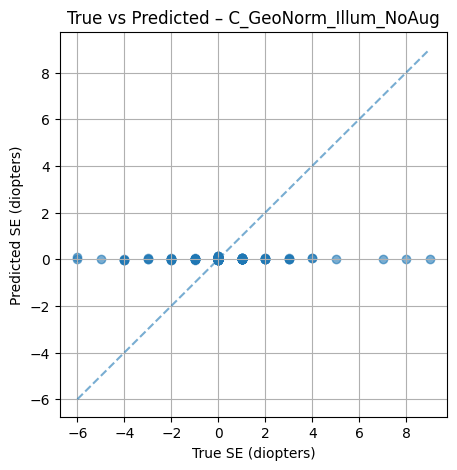

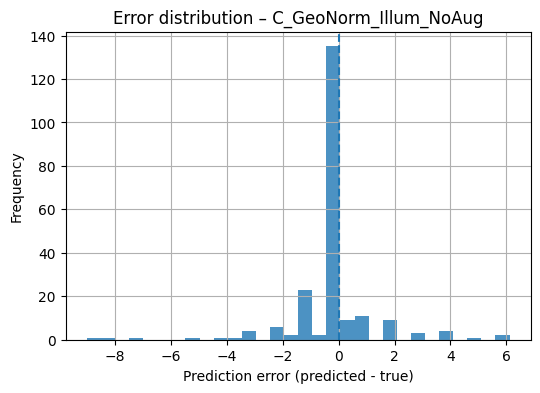

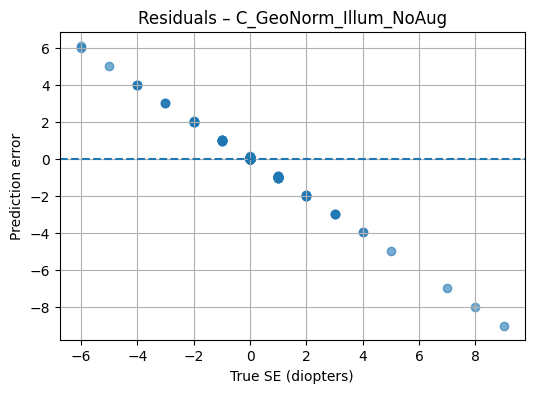

{'name': 'C_GeoNorm_Illum_NoAug', 'MAE': 0.7567947261284367, 'MSE': 2.6658024234774267, 'RMSE': 1.6327285210583622, 'R2': -0.0019792972584133928, 'mean_error': -0.06824464539349216, 'std_error': 1.631301655688654}

===== Running D_GeoNorm_Aug_NoIllum =====
Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - loss: 4.2107 - mae: 1.1804 - mse: 4.2107 - val_loss: 3.4789 - val_mae: 1.0405 - val_mse: 3.4789 - learning_rate: 0.0010
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - loss: 4.9718 - mae: 1.2713 - mse: 4.9718 - val_loss: 3.4191 - val_mae: 1.0036 - val_mse: 3.4191 - learning_rate: 0.0010
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - loss: 4.5873 - mae: 1.2408 - mse: 4.5873 - val_loss: 3.4108 - val_mae: 1.0051 - val_mse: 3.4108 - learning_rate: 0.0010
Epoch 4/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - loss: 4.7818 - mae: 1.2789 - mse: 4.7818 - val_loss: 3.4180 - val_mae: 1.0112 - val_mse: 3.4180 - learning_rate: 0.0010
Epoch 5/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - los

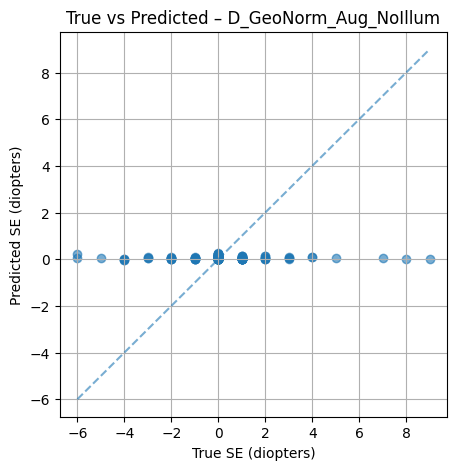

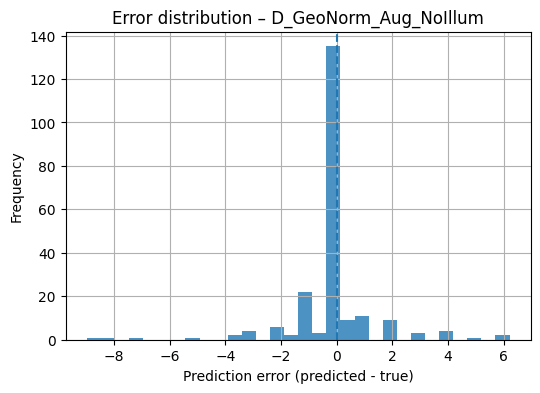

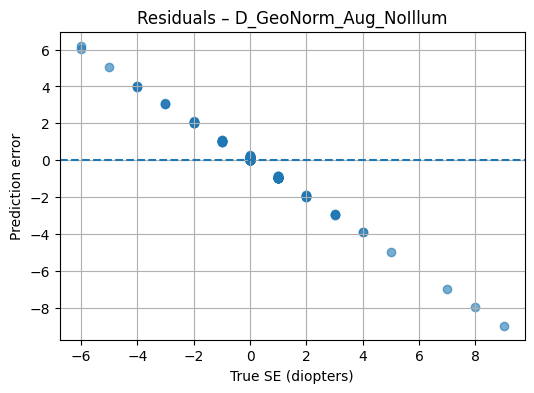

{'name': 'D_GeoNorm_Aug_NoIllum', 'MAE': 0.7764361856101845, 'MSE': 2.664825793466411, 'RMSE': 1.6324294145433704, 'R2': -0.0016122171464361124, 'mean_error': -0.03289508781812158, 'std_error': 1.6320979464063572}


,name,task,preprocessing_family,dropout,augmentation,normalization,best_val_mae,best_val_mse,test_mae,test_mse,test_rmse,test_r2,mean_error,std_error,model_path
0,A_Raw_minimal,regression,SelectivePreproc,True,False,0-1,0.996220,3.387681,0.751571,2.666531,1.632952,-0.002253,-0.073259,1.631307,C:\Users\paula\0B_TFGBiomed_Exe\ModelsToSave\W...
1,B_GeoNorm,regression,SelectivePreproc,True,False,0-1,1.007427,3.340330,0.777140,2.670485,1.634162,-0.003739,-0.105127,1.630777,C:\Users\paula\0B_TFGBiomed_Exe\ModelsToSave\W...
2,C_GeoNorm_Illum_NoAug,regression,SelectivePreproc,True,False,0-1,0.997731,3.403910,0.756795,2.665802,1.632729,-0.001979,-0.068245,1.631302,C:\Users\paula\0B_TFGBiomed_Exe\ModelsToSave\W...
3,D_GeoNorm_Aug_NoIllum,regression,SelectivePreproc,True,True,0-1,1.003587,3.363293,0.776436,2.664826,1.632429,-0.001612,-0.032895,1.632098,C:\Users\paula\0B_TFGBiomed_Exe\ModelsToSave\W...


In [13]:
results = []
models  = {}
histories = {}
datasets = {}

for exp in EXPERIMENTS:
    mdl, hist, metrics, ds_tuple = run_experiment(exp, epochs=10)

    name = exp["name"]
    models[name] = mdl
    histories[name] = hist
    datasets[name] = ds_tuple

    model_path = MODELS_DIR_SELECTIVE / f"small_cnn_regression_with_dropout_{name}.keras"
    mdl.save(model_path)

    results.append({
        "name": name,
        "task": "regression",
        "preprocessing_family": "SelectivePreproc",
        "dropout": True,
        "augmentation": exp["do_aug"],
        "normalization": exp["normalization"],
        "best_val_mae": float(np.min(hist.history.get("val_mae", [np.nan]))),
        "best_val_mse": float(np.min(hist.history.get("val_mse", [np.nan]))),
        "test_mae": metrics["MAE"],
        "test_mse": metrics["MSE"],
        "test_rmse": metrics["RMSE"],
        "test_r2": metrics["R2"],
        "mean_error": metrics["mean_error"],
        "std_error": metrics["std_error"],
        "model_path": str(model_path)
    })

results_df = pd.DataFrame(results)
results_df

The results table shows a comparative of the same model (small_cnn_classf) run over the 4 different sets of preprocessed pictures:
- best_val_auc: best AUC value (capacity of model to distinguish classes) obtained accross the 10 epochs on the **validation set** (1 perfect, 0.5 random)
- best_val_acc: best accuracy value (% of right guesses) obtained accross the 10 epochs on the **validation set** (watch out for unbalanced classes in dataset)
- test_auc: AUC obtained on **test set**. This might be the most important metric
- test_ap: average precision obtained on **test set** (area under precision-recall curve). Very useful with unbalanced classes since it focuses on performance on myopia class
- test_acc@0.5: accuracy obtained on **test set** when 0.5 threshold is applied (≥ 0.5 means myopia); < 0.5 means normal)

All in all:
- AUC shows how well the model distinguishes amongst classes
- Accuracy shows % of right guesses when classifying
- AP shows how well the model handles the minority class (looking at precision vs recall)


Note 1: if overfitting is seen we may increase the dropout rate, add L2 on Conv2D or increase augmentations.

Note 2: handling the smaller class (AP) can be complicated since, if there is a large picture number difference amongst classes, the model might learn to state it is almost always right to predict that a picture belongs to the larger group when classifying.

A/B/C/D regression results:

The four selective preprocessing scenarios produce very similar regression results. The best MAE is obtained by **A_Raw_minimal** with **MAE = 0.7516 D**, followed by **C_GeoNorm_Illum_NoAug** with **MAE = 0.7568 D**. The other two scenarios are slightly worse, with **B_GeoNorm = 0.7771 D** and **D_GeoNorm_Aug_NoIllum = 0.7764 D**.

However, these MAE differences are small and should not be interpreted as meaningful model improvement. The most important result is that **all R² values are approximately zero and slightly negative**: from **-0.0037** to **-0.0016**. This means that none of the models explains the variability of SE better than a simple baseline that predicts a central value for all samples.

The prediction plots confirm this interpretation. In all four scenarios, the predicted SE values are almost flat and clustered around **0 D**, regardless of the true SE value. This indicates that the network has not learned a useful continuous mapping from retinal image appearance to SE. Instead, it has converged towards predicting the central tendency of the dataset.

The residual plots also show a very clear diagonal pattern: negative true SE values tend to produce positive errors, while positive true SE values tend to produce negative errors. This is usually what happens when a model predicts approximately the same value for every case.

-> Therefore, although **A_Raw_minimal** has the best MAE and **D_GeoNorm_Aug_NoIllum** has the least negative R², the practical conclusion is that **none of the selective preprocessing scenarios produces a successful regression model in this notebook**.


Results table:

The results table compares the same **small_cnn regression model with Dropout** across the four selective preprocessing scenarios.

Numerically, **A_Raw_minimal** obtains the lowest test MAE (**0.7516 D**), while **D_GeoNorm_Aug_NoIllum** obtains the lowest RMSE (**1.6324 D**) and the least negative R² (**-0.0016**). However, the differences between scenarios are extremely small.

->The key point is not which scenario wins by a few decimal places, but that **all test R² values are approximately zero**. This means that the model does not explain SE variability in a meaningful way. The model behaves similarly to a baseline predictor that returns a value close to the mean or median of the training distribution.

Therefore, the table should be interpreted as evidence that none of the selective preprocessing pipelines produces a robust regression model in this configuration.


⚠️ Important note for interpreting this regression notebook

In this notebook, **MAE is not enough to claim good regression performance**. Since SE values are concentrated around **0 D**, a model can reach a moderate MAE by predicting values close to zero for most images.

For this reason, the most important evidence comes from the combination of: **R² close to zero**, true-vs-predicted plots forming a horizontal line, and residual plots showing a strong diagonal pattern.

Together, these results indicate that the model has not learned a useful image-based SE estimator.


## 📊 4. Results

#### 📈 4.1 Plot histories
Plotting training and validation curves (AUC, accuracy, or loss) for Keras models, making it easy to compare performance across epochs.

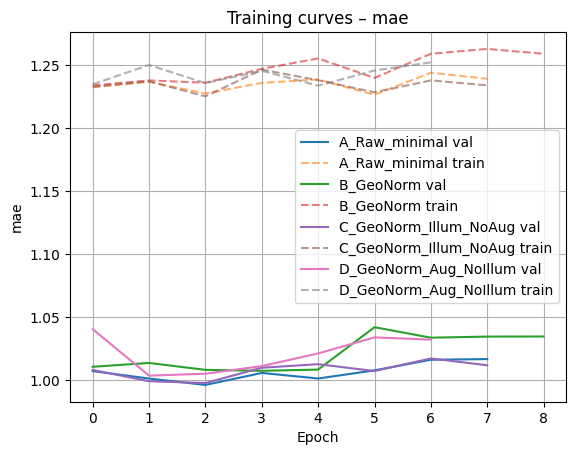

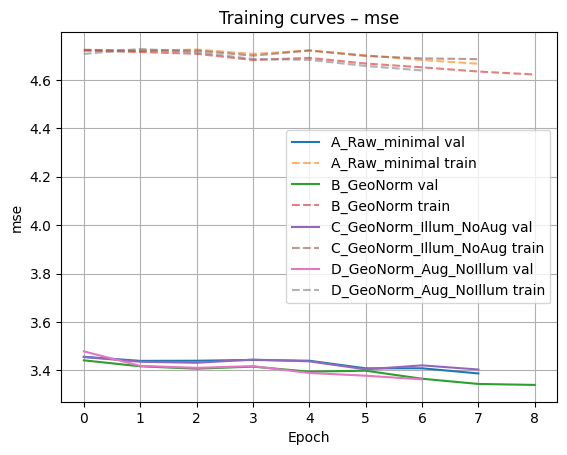

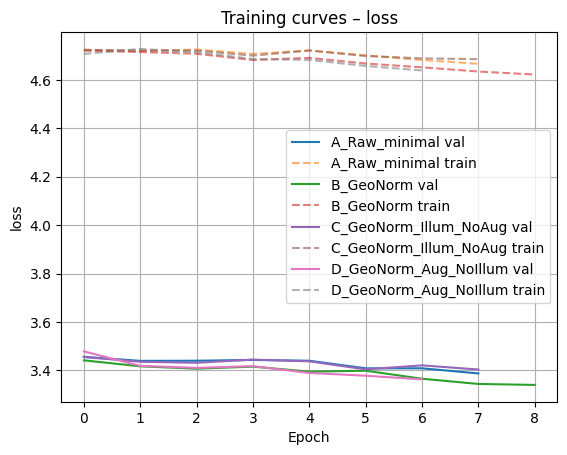

In [14]:
def plot_histories(histories, metric="mae"):
    #histories: list of keras History objects
    for name, history in histories.items():
        if f"val_{metric}" in history.history:
            plt.plot(history.history[f"val_{metric}"], label=f"{name} val")

        if metric in history.history:
            plt.plot(
                history.history[metric],
                linestyle="--",
                alpha=0.6,
                label=f"{name} train"
            )

    plt.xlabel("Epoch")
    plt.ylabel(metric)
    plt.title(f"Training curves – {metric}")
    plt.legend()
    plt.grid(True)
    plt.show()

#Let's have them set side by side to compare
plot_histories(histories, metric="mae")
plot_histories(histories, metric="mse")
plot_histories(histories, metric="loss")

The training curves show that the validation MAE remains close to **1.0 D** across all scenarios and does not improve substantially over the epochs. **The curves are relatively flat, which suggests that the model reaches a very simple solution early in training.**

The training MAE is higher than the validation MAE, especially in the augmented scenario. This does not necessarily indicate a better validation performance; it is likely influenced by **Dropout and training-time augmentations, which make the training task noisier**. The validation set, in contrast, is evaluated without these random transformations.

The MSE and loss curves decrease slightly in validation, but this does not translate into a meaningful improvement in R². This reinforces the idea that the model mainly learns to predict values close to the centre of the SE distribution.

Overall, the training curves do not show strong overfitting. The more relevant issue is **underfitting/prediction collapse**: the model does not learn enough image-based information to predict continuous SE values.


#### ⚖️ 4.2 Direct comparison A vs B vs C vs D on ROC & PR
This code evaluates multiple outcomes on the same test set, computes ROC and Precision–Recall curves (with AUC and AP), and overlays the curves to compare their performance directly.

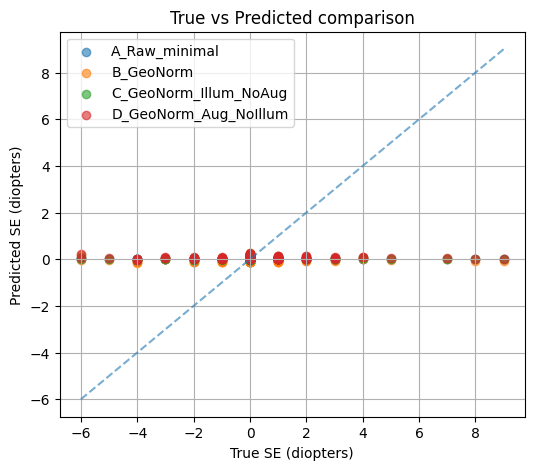

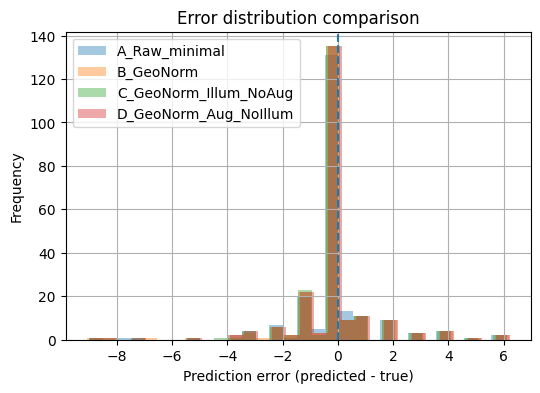

In [15]:
def compare_models_on_test(model_dict, scenario_splits, normalization="0-1"):
    comparison = {}

    for name, model in model_dict.items():
        test_csv = scenario_splits[name]["test"]

        test_ds = make_ds(test_csv, training=False, normalization=normalization, do_aug=False)
        y_true, y_pred = collect_preds(model, test_ds)
        errors = y_pred - y_true

        comparison[name] = {
            "y_true": y_true,
            "y_pred": y_pred,
            "errors": errors
        }

    plt.figure(figsize=(6, 5))
    
    for name, d in comparison.items():
        plt.scatter(d["y_true"], d["y_pred"], alpha=0.6, label=name)

    all_true = np.concatenate([d["y_true"] for d in comparison.values()])
    all_pred = np.concatenate([d["y_pred"] for d in comparison.values()])

    min_val = min(all_true.min(), all_pred.min())
    max_val = max(all_true.max(), all_pred.max())

    plt.plot([min_val, max_val], [min_val, max_val], "--", alpha=0.6)
    plt.xlabel("True SE (diopters)")
    plt.ylabel("Predicted SE (diopters)")
    plt.title("True vs Predicted comparison")
    plt.legend()
    plt.grid(True)
    plt.show()
    plt.figure(figsize=(6, 4))

    for name, d in comparison.items():
        plt.hist(d["errors"], bins=30, alpha=0.4, label=name)

    plt.axvline(0, linestyle="--")
    plt.xlabel("Prediction error (predicted - true)")
    plt.ylabel("Frequency")
    plt.title("Error distribution comparison")
    plt.legend()
    plt.grid(True)
    plt.show()

    return comparison


regression_comparison = compare_models_on_test(
    models,
    SCENARIO_SPLITS,
    normalization="0-1"
)

:Direct comparison plots
- The direct comparison plots make the central result of the notebook very clear. In the true-vs-predicted plot, all four preprocessing scenarios form an almost horizontal line around **0 D**. This means that the predicted SE barely changes across the test set, even when the true SE varies from negative myopic values to positive hyperopic values.
- The error distributions are also almost completely overlapped across scenarios. This shows that the different preprocessing strategies do not substantially change the regression behaviour of the model.
- The comparison therefore confirms that the model is not learning a clinically useful SE prediction. The similar MAE and RMSE values across A, B, C and D are not due to all scenarios performing well, but rather to all scenarios collapsing towards the same mean-like prediction strategy.
- From these plots, the most defensible conclusion is that **selective preprocessing does not solve the regression problem for this small CNN with Dropout**.

#### 📝 4.3 Conclusions

The dataset contains **2,126 images** with available SE values. The SE distribution is highly centred around **0 D**, with a median of **0 D** and most samples located between **-0.25 D** and **0.75 D**. This makes the regression task difficult to evaluate using MAE alone, because a mean-like predictor can already obtain a moderate absolute error.

- The results show that all four preprocessing scenarios produce very similar test performance. **A_Raw_minimal** gives the lowest MAE (**0.7516 D**), while **D_GeoNorm_Aug_NoIllum** gives the least negative R² (**-0.0016**). However, these small numerical differences are not meaningful because all R² values remain approximately zero and slightly negative.
- The prediction plots show that the model predicts values very close to **0 D** for almost every test image. This confirms that the network has collapsed towards the central tendency of the target distribution instead of learning a real mapping between retinal appearance and SE.
 -The residual plots reinforce the same conclusion: errors follow a diagonal pattern, which is characteristic of a model that predicts almost the same value for all samples. Negative SE values are systematically underestimated in magnitude, while positive SE values are also pulled back towards zero.

Therefore, this notebook does not provide a successful SE regression model. Selective preprocessing with Dropout does not solve the regression problem for this small CNN architecture. The results suggest that direct image-only SE regression is substantially harder than binary myopia classification in this dataset.

-> The most important conclusion is that **the regression model does not outperform a mean-like baseline in a clinically meaningful way**, despite small differences in MAE between preprocessing scenarios. Future experiments should focus on alternative strategies, such as removing Dropout, changing the loss function, using stronger architectures, incorporating metadata, or reframing the task as classification rather than direct SE regression.

All in all:

When the small CNN with Dropout was trained for SE regression using selectively preprocessed images, all preprocessing scenarios produced very similar results. Although the raw-minimal scenario achieved the lowest MAE, all models obtained R² values close to zero and predicted values concentrated around 0 D. This indicates that the models mainly learned the central tendency of the SE distribution rather than a meaningful image-based refractive prediction. Therefore, selective preprocessing did not provide a successful solution for direct SE regression in this configuration.

End :)